In [ ]:

import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn  # Import neural network module
import torch.optim as optim  # Import optimization module
import src
from src.data.synthetic_data import SyntheticDataGenerator
from src.data.dataset import KineticDataset, Normalize
from src.data.data_loader import get_data_loaders
from src.models.crnn import CRNN
from src.models.loss_fn import RangeNormalizedMAE, RangeNormalizedMSE
# For one step reaction
y0 = {
    'S_1' : (20, 60),
    'S_2' : (20, 60),
    'S_out' : (0, 0),
}
ks = [2e4*1e-9]

time_hours = 1 #hours
t_end = time_hours * 3600  # seconds

data_gen = SyntheticDataGenerator(
    mechanism='one_step',
    reaction_rates=ks,
    initial_concentration_ranges=y0,
    noise_level=0,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
)

batch_size = 6
batch = data_gen.generate_batch(batch_size)
ds = KineticDataset(batch)

norm = Normalize()

ImportError: cannot import name 'Normalize' from 'src.data.dataset' (/homes/gws/tiernan7/Projects/DSD-CRNN/src/data/dataset.py)

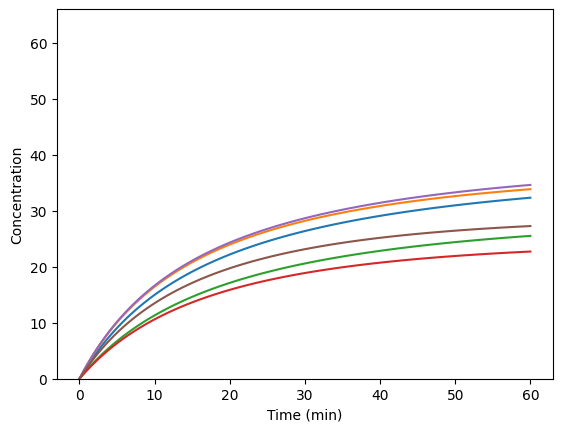

In [ ]:
# Visualize kinetics for each sample on a single plot
t = ds.get_t().numpy()
for i in range(batch_size):
    sett = norm(ds[i])
    y = sett['y'].numpy()
    plt.plot(t/60, y, label=f'Sample {i}')
plt.xlabel('Time (min)')
plt.ylabel('Concentration')
plt.ylim(0, max(y0['S_2'][1]*1.1, y0['S_1'][1]*1.1))
plt.show()

In [12]:
# Get the data loaders ready
n_total = len(ds)
n_train = 1
n_test = 3
n_val = n_total - n_train - n_test


train_ds, test_ds, val_ds = torch.utils.data.random_split(
    ds, [n_train, n_test, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader, test_loader, val_loader = get_data_loaders(
    train_ds, test_ds, val_ds,
    batch_size=1
)

# Known species experiment

In [13]:
# global constants pulled from the *base dataset*
base_ds = train_ds.dataset  # original KineticDataset
A_control = base_ds.get_A().detach().cpu().numpy()         # for scipy.null_spa
out_ind = base_ds.get_output_index()
out_ind = int(out_ind.item()) if torch.is_tensor(out_ind) else int(out_ind)

num_reactions = 1
epochs = 2000
learning_rate = 1e-1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = RangeNormalizedMSE()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true)
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/2000 | loss 0.595057
Epoch 101/2000 | loss 0.002512
Epoch 201/2000 | loss 0.001976
Epoch 301/2000 | loss 0.001475
Epoch 401/2000 | loss 0.001050
Epoch 501/2000 | loss 0.000721
Epoch 601/2000 | loss 0.000479
Epoch 701/2000 | loss 0.000309
Epoch 801/2000 | loss 0.000193
Epoch 901/2000 | loss 0.000118


KeyboardInterrupt: 

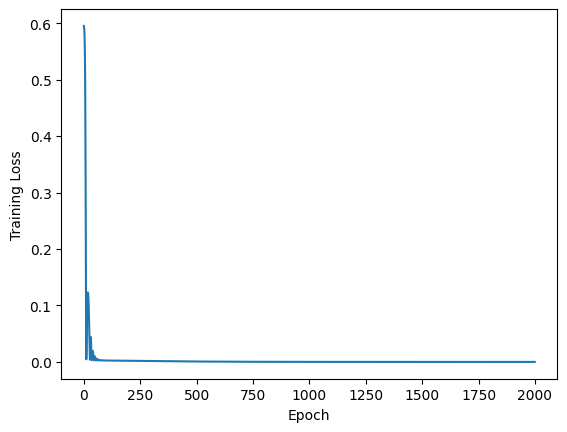

Learned reaction rates: [20270.229]
Reaction stoiciometry
[[-0.998219 ]
 [-0.9982189]
 [ 0.998219 ]]


In [6]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

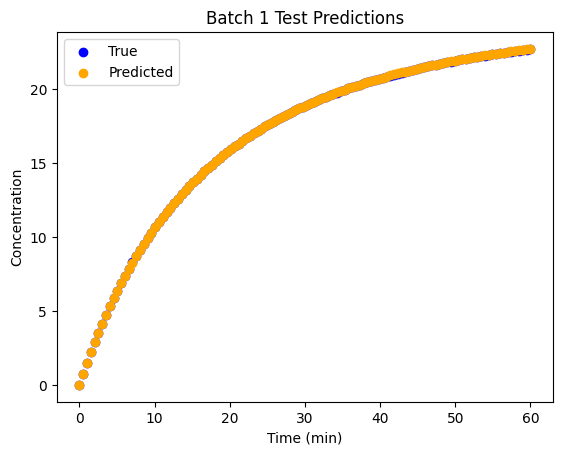

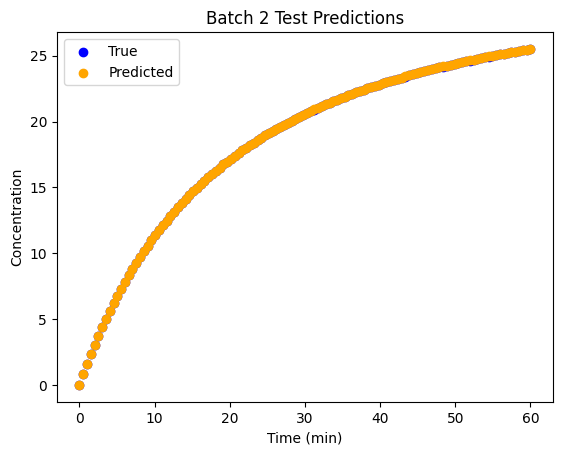

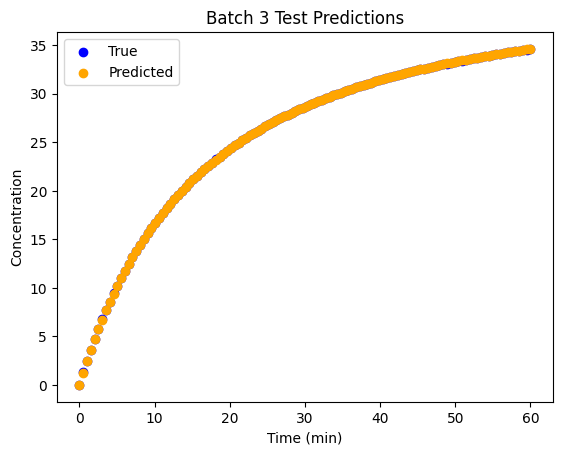

In [7]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

# Unknown spexies experiment